# Task 2: Customer Segmentation Using Unsupervised Learning
**DevelopersHub Corporation — Data Science & Analytics Advanced Internship**

---

## 🎯 Objective
Cluster customers based on spending habits using K-Means, visualize with PCA / t-SNE,  
and propose tailored marketing strategies for each segment.

**Dataset:** Mall Customers Dataset (`Mall_Customers.csv`)


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## 2. Load & Explore the Dataset
> 📌 Place `Mall_Customers.csv` in the same directory as this notebook.


In [2]:
df = pd.read_csv('Mall_Customers.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()


Shape: (200, 5)

Column names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Descriptive Statistics ===")
df.describe()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Descriptive Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Exploratory Data Analysis (EDA)

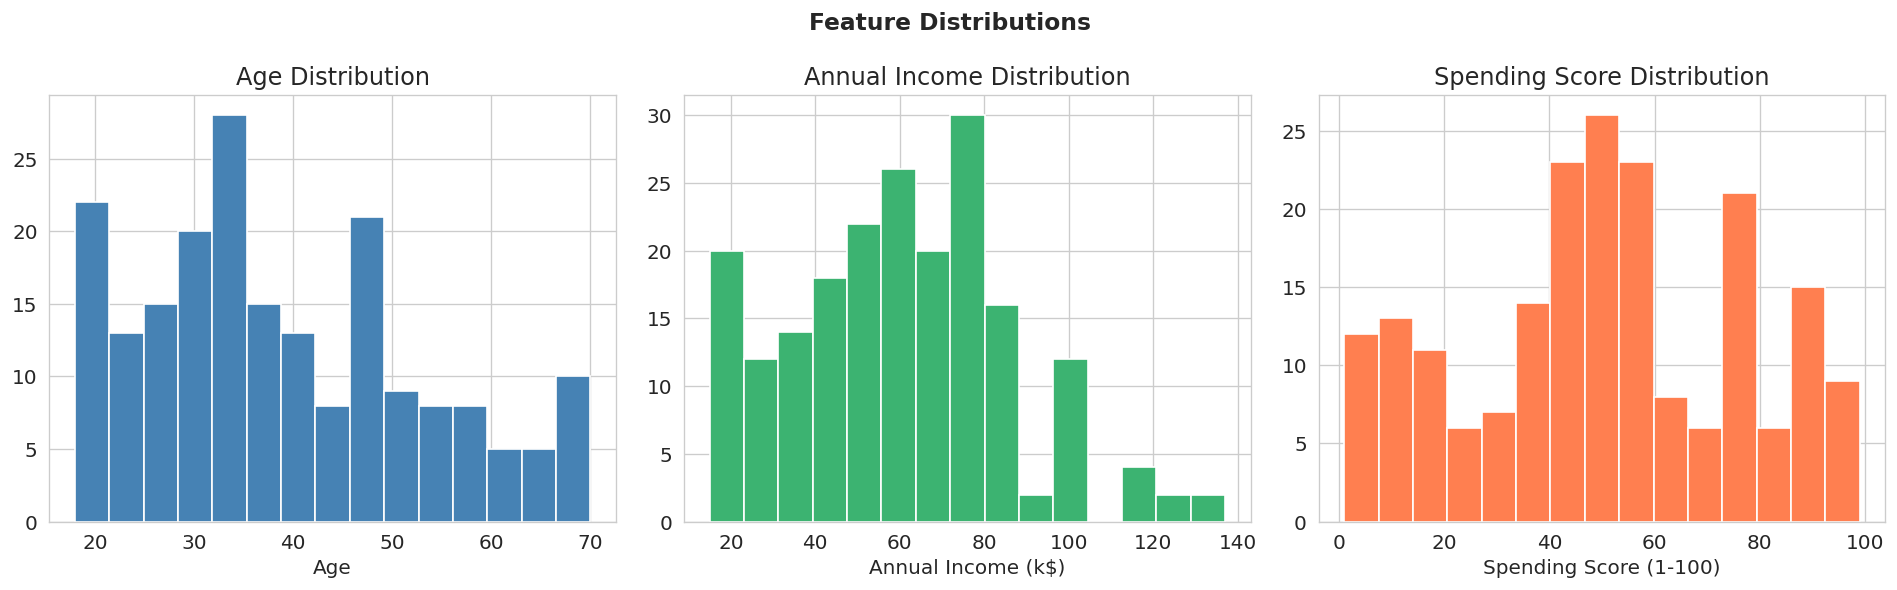

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

axes[1].hist(df['Annual Income (k$)'], bins=15, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(df['Spending Score (1-100)'], bins=15, color='coral', edgecolor='white')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


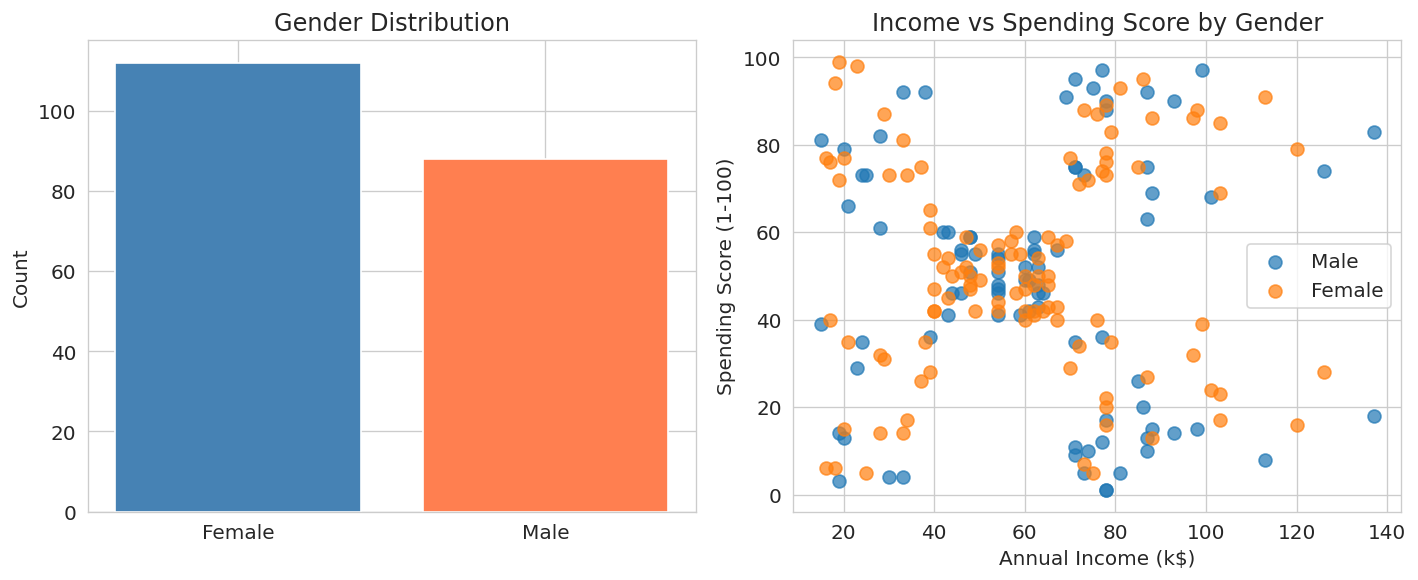

In [5]:
# Gender distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df['Genre'].value_counts() if 'Genre' in df.columns else df['Gender'].value_counts()
gender_col = 'Genre' if 'Genre' in df.columns else 'Gender'

ax1.bar(gender_counts.index, gender_counts.values, color=['steelblue', 'coral'], edgecolor='white')
ax1.set_title(f'{gender_col} Distribution')
ax1.set_ylabel('Count')

# Spending Score vs Annual Income by Gender
for gender in df[gender_col].unique():
    subset = df[df[gender_col] == gender]
    ax2.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                label=gender, alpha=0.7, s=60)
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.set_title('Income vs Spending Score by Gender')
ax2.legend()

plt.tight_layout()
plt.show()


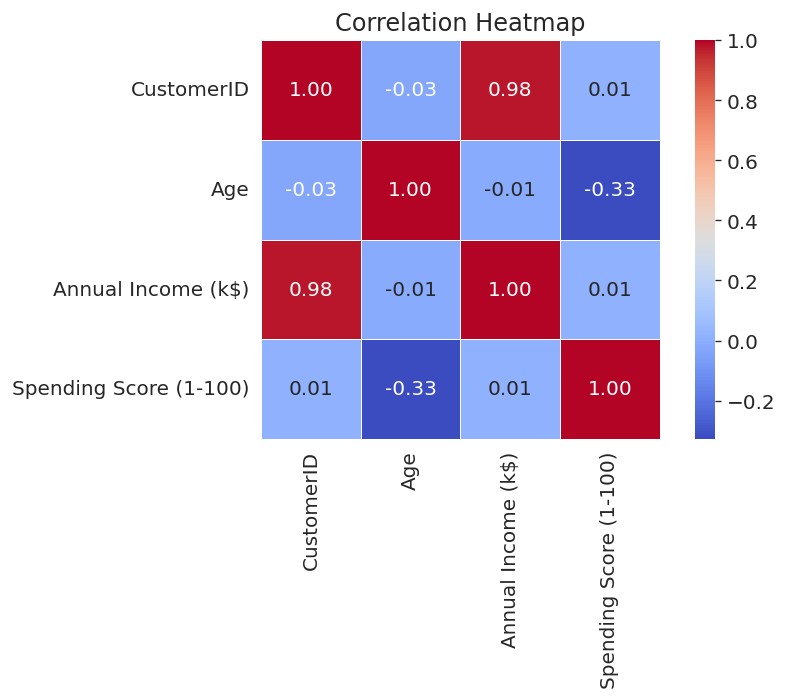

In [6]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [7]:
gender_col = 'Genre' if 'Genre' in df.columns else 'Gender'

# Encode gender
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df[gender_col])

# Features for clustering (use Income & Spending Score — most meaningful for marketing)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
X_full = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_full_scaled = scaler.fit_transform(X_full)

print("Features prepared and scaled ✅")
print(f"Shape: {X_scaled.shape}")


Features prepared and scaled ✅
Shape: (200, 2)


## 5. Finding Optimal Number of Clusters

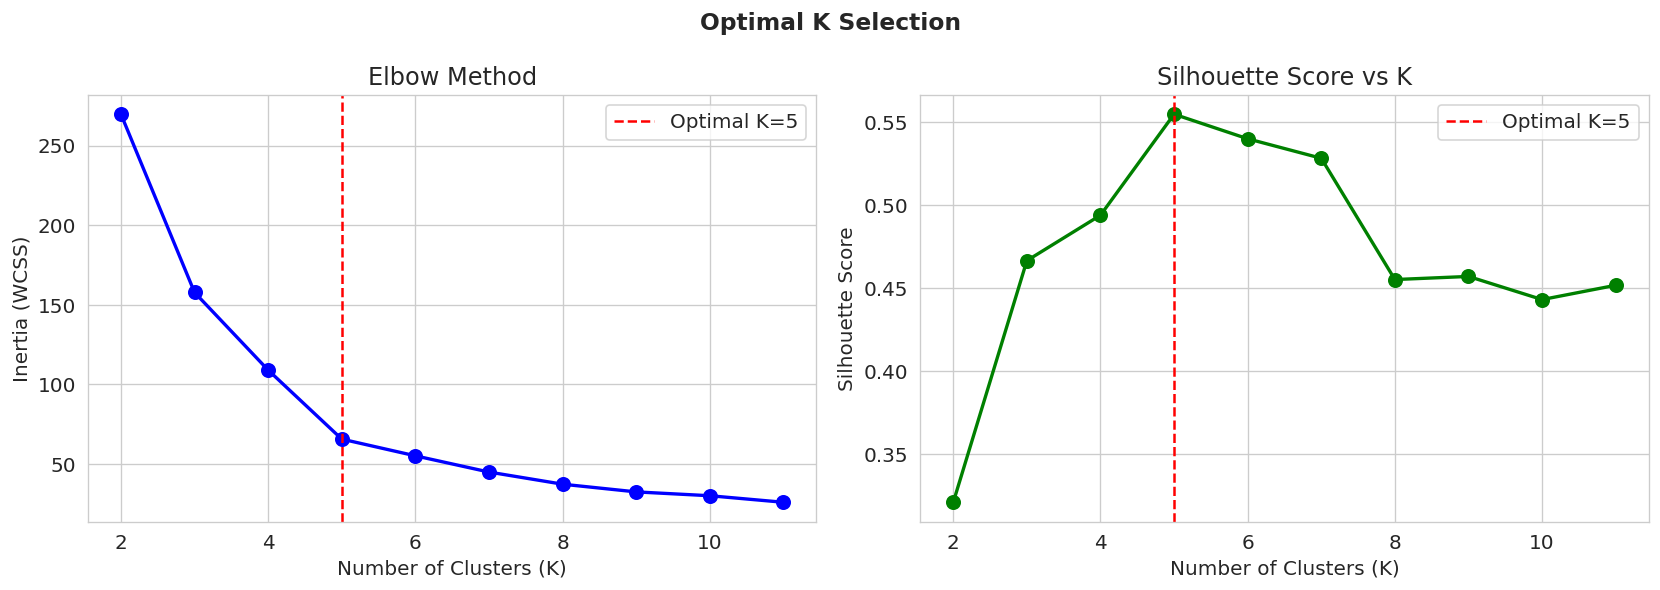

Best K by Silhouette Score: 5
Silhouette Scores: {2: 0.321, 3: 0.467, 4: 0.494, 5: 0.555, 6: 0.54, 7: 0.528, 8: 0.455, 9: 0.457, 10: 0.443, 11: 0.452}


In [8]:
inertias = []
sil_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax1.legend()

ax2.plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax2.legend()

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Best K by Silhouette Score: {best_k}")
print(f"Silhouette Scores: {dict(zip(K_range, [round(s,3) for s in sil_scores]))}")


## 6. K-Means Clustering (K=5)

In [9]:
K_OPTIMAL = 5  # Classic result for Mall Customers dataset

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means with K={K_OPTIMAL} complete ✅")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())


K-Means with K=5 complete ✅
Silhouette Score: 0.5547

Cluster distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


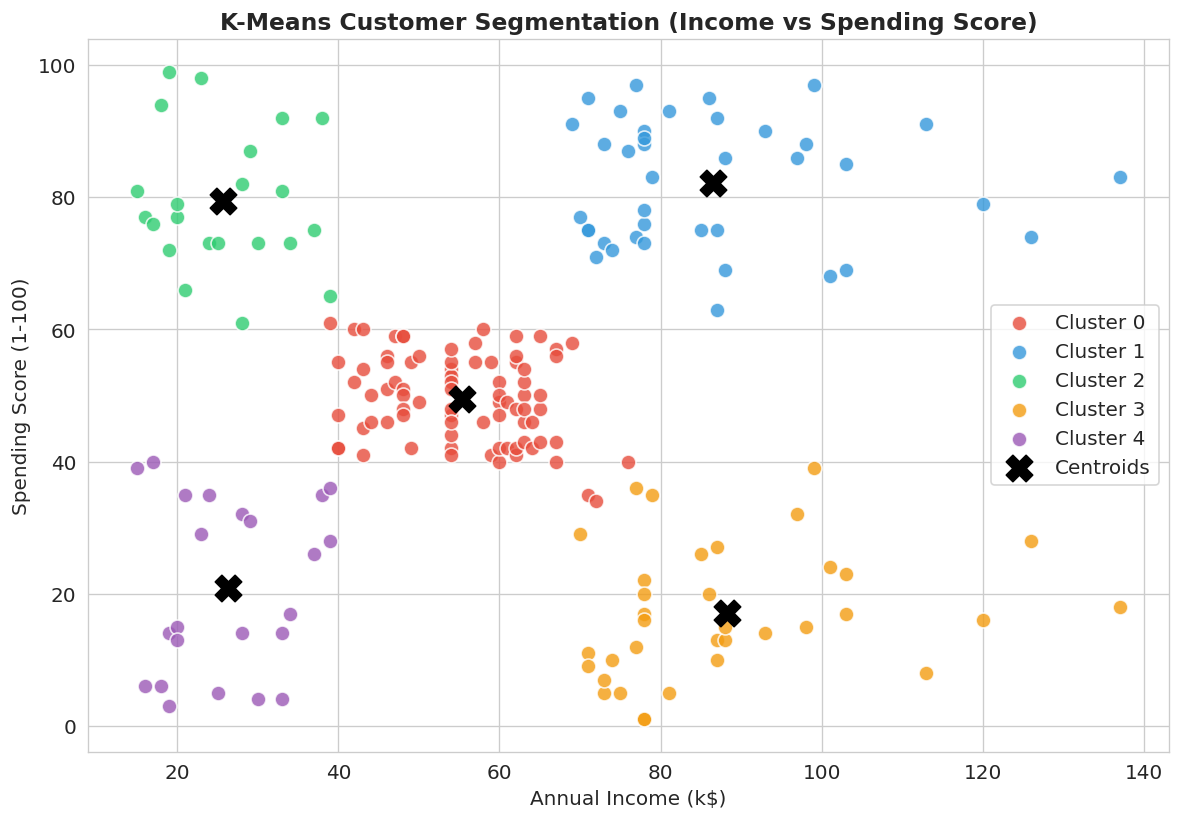

In [10]:
# Visualize the clusters (Income vs Spending Score)
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6"]

plt.figure(figsize=(10, 7))
for i in range(K_OPTIMAL):
    cluster_data = df[df["Cluster"] == i]
    plt.scatter(cluster_data["Annual Income (k$)"],
                cluster_data["Spending Score (1-100)"],
                c=colors[i], label=f"Cluster {i}", s=80, alpha=0.8, edgecolors="white")

# Inverse transform centroids using the 2-feature scaler
sc2 = StandardScaler()
sc2.fit(X)
centers_orig = sc2.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_orig[:, 0], centers_orig[:, 1],
            c="black", s=250, marker="X", zorder=5, label="Centroids")

plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.title("K-Means Customer Segmentation (Income vs Spending Score)", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Dimensionality Reduction — PCA Visualization

Explained Variance Ratio: [0.33690046 0.26230645]
Total Variance Explained: 59.92%


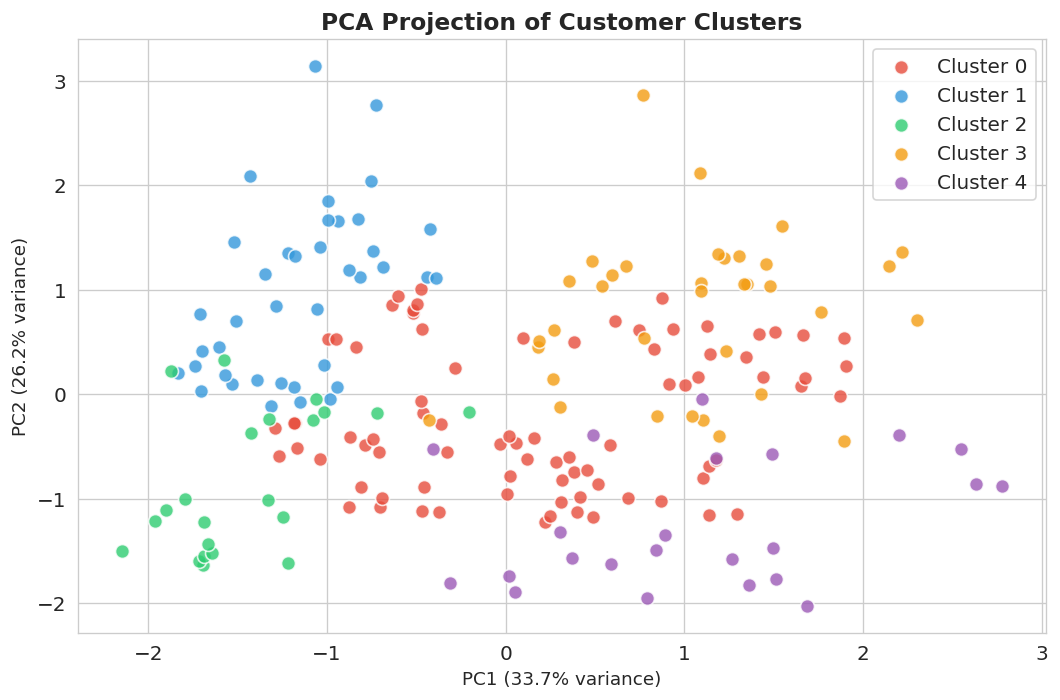

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(9, 6))
for i in range(K_OPTIMAL):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}', s=70, alpha=0.8, edgecolors='white')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.title('PCA Projection of Customer Clusters', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Dimensionality Reduction — t-SNE Visualization

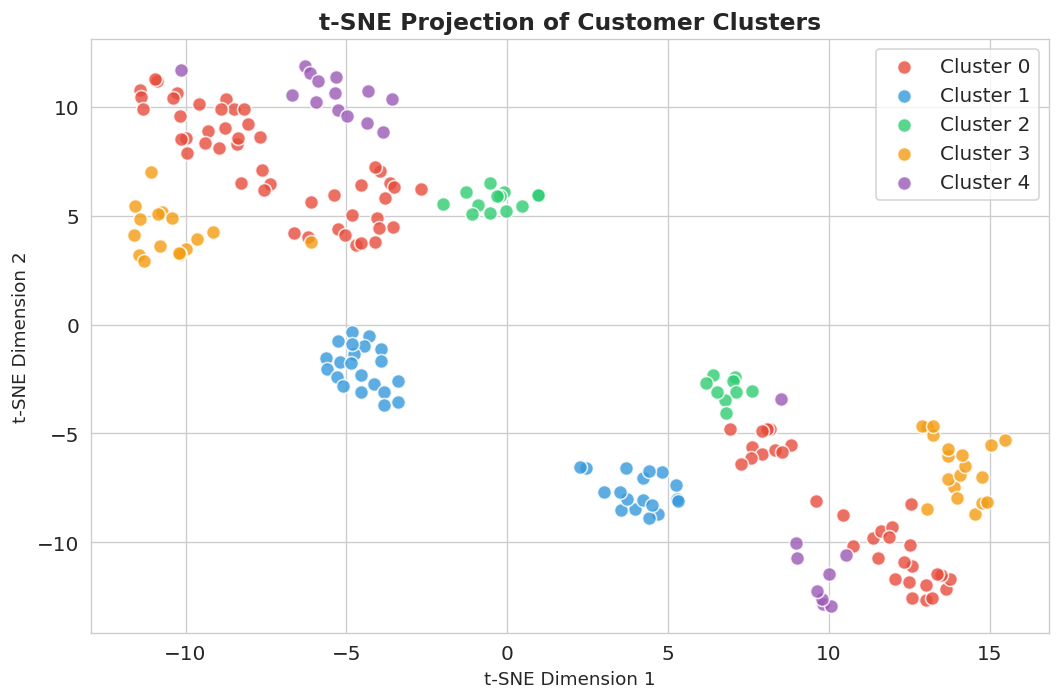

In [12]:
# t-SNE is stochastic — random_state ensures reproducibility
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_full_scaled)

plt.figure(figsize=(9, 6))
for i in range(K_OPTIMAL):
    mask = df['Cluster'] == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[i], label=f'Cluster {i}', s=70, alpha=0.8, edgecolors='white')

plt.xlabel('t-SNE Dimension 1', fontsize=11)
plt.ylabel('t-SNE Dimension 2', fontsize=11)
plt.title('t-SNE Projection of Customer Clusters', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Cluster Profiling — Who Are These Customers?

In [13]:
gender_col = 'Genre' if 'Genre' in df.columns else 'Gender'

cluster_profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending_Score=('Spending Score (1-100)', 'mean')
).round(2)

print("=== Cluster Profiles ===")
print(cluster_profile)


=== Cluster Profiles ===
         Count  Avg_Age  Avg_Income  Avg_Spending_Score
Cluster                                                
0           81    42.72       55.30               49.52
1           39    32.69       86.54               82.13
2           22    25.27       25.73               79.36
3           35    41.11       88.20               17.11
4           23    45.22       26.30               20.91


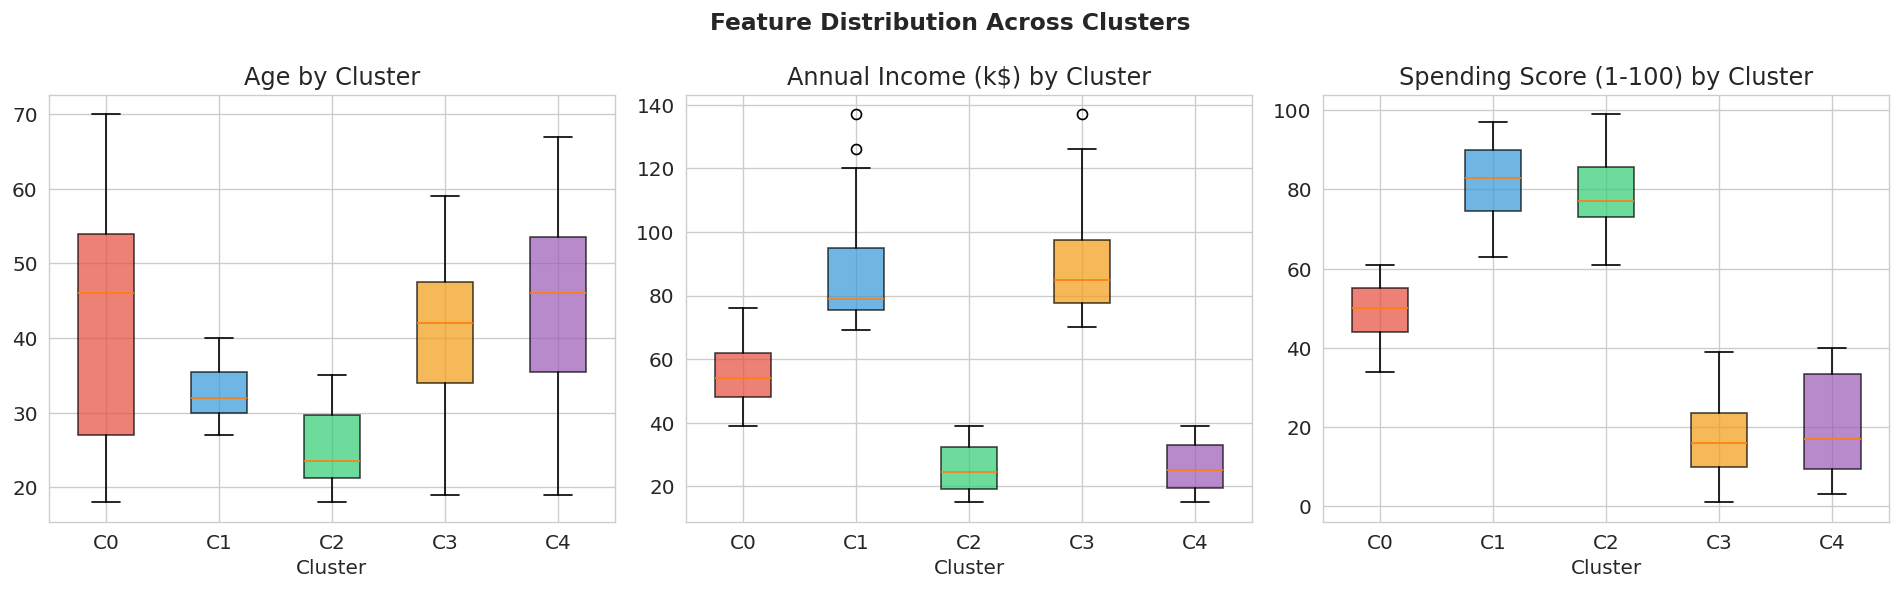

In [14]:
# Box plots per cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for ax, feat in zip(axes, features):
    data_by_cluster = [df[df['Cluster'] == i][feat].values for i in range(K_OPTIMAL)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    labels=[f'C{i}' for i in range(K_OPTIMAL)])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{feat} by Cluster')
    ax.set_xlabel('Cluster')

plt.suptitle('Feature Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Marketing Strategies Per Segment

Based on the cluster profiles (typical Mall Customers result with K=5):

| Cluster | Profile | Label | Marketing Strategy |
|---------|---------|-------|-------------------|
| **0** | Low Income, Low Spending | 💤 Careful Spenders | Budget deals, loyalty points, value-for-money promotions |
| **1** | High Income, Low Spending | 💼 Potential Big Spenders | Premium product introductions, exclusive previews, personalized offers |
| **2** | Middle Income, Middle Spending | 😊 Average Customers | Seasonal campaigns, bundled offers, moderate discounts |
| **3** | Low Income, High Spending | 🛍️ Impulsive Buyers | Flash sales, FOMO marketing, limited-time discounts |
| **4** | High Income, High Spending | 👑 Prime Customers | VIP memberships, luxury campaigns, early-access privileges |

> **Note:** Actual cluster labels may vary. Always re-check the cluster profiles table above and re-map accordingly.


## 11. Conclusion & Insights

### Summary
- Applied **K-Means clustering** (K=5) to segment 200 mall customers.
- Used **Elbow Method** and **Silhouette Score** to confirm the optimal number of clusters.
- **PCA** and **t-SNE** both show clear visual separation between segments.
- Identified **5 distinct customer groups** based on income and spending behavior.

### Key Insights
1. **High-Income, High-Spending** customers (Prime) are the most valuable — target with VIP programs.
2. **High-Income, Low-Spending** customers represent untapped potential — needs personalized engagement.
3. **Low-Income, High-Spending** customers are impulsive — respond to urgency-driven promotions.
4. **Careful Spenders** need value-centric communication to convert.

### Tools Used
`pandas` · `scikit-learn` · `matplotlib` · `seaborn` · `PCA` · `t-SNE` · `KMeans`
